### General Results of the optimisation

In [1]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Get latest run
RESULTS_ROOT = Path("02-MODEL-RESULTS")
latest_run = sorted([d for d in RESULTS_ROOT.iterdir() if d.is_dir()])[-1]

# Load summary
with open(latest_run / "results_summary.json", "r") as f:
    summary = json.load(f)

# Load time series
df = pd.read_csv(latest_run / "timeseries_results.csv", parse_dates=['timestamp'])
df_soc = df.copy()
df_compare = pd.read_csv(latest_run / "baseline_vs_optimized.csv")
df_peak_metrics = pd.read_csv(latest_run / "peak_metrics.csv")
df_top_peaks = pd.read_csv(latest_run / "top_peak_intervals.csv", parse_dates=['timestamp'])
monthly_summary_path = latest_run / "monthly_summary.csv"
if monthly_summary_path.exists():
    df_monthly = pd.read_csv(monthly_summary_path)
else:
    df_monthly = df.copy()
    df_monthly["month"] = df_monthly["timestamp"].dt.to_period("M").astype(str)
    price_per_kwh = 0.0
    if len(df_monthly) > 0 and df_monthly["grid_flow"].sum() > 0:
        price_per_kwh = summary.get("import_cost", 0.0) / (df_monthly["grid_flow"].sum() * 0.25)
    df_monthly["baseline_import_cost"] = df_monthly["baseline_grid_import"] * price_per_kwh * 0.25
    df_monthly["optimized_import_cost"] = df_monthly["grid_flow"] * price_per_kwh * 0.25
    df_monthly = df_monthly.groupby("month", as_index=False).agg(
        monthly_import_cost_before=("baseline_import_cost", "sum"),
        monthly_import_cost_after=("optimized_import_cost", "sum"),
        monthly_peak_before=("baseline_grid_import", "max"),
        monthly_peak_after=("grid_flow", "max"),
    )
    df_monthly["monthly_savings"] = df_monthly["monthly_import_cost_before"] - df_monthly["monthly_import_cost_after"]
    df_monthly["monthly_peak_reduction"] = df_monthly["monthly_peak_before"] - df_monthly["monthly_peak_after"]
battery_utilization_path = latest_run / "battery_utilization_summary.csv"
if battery_utilization_path.exists():
    df_battery_util = pd.read_csv(battery_utilization_path)
elif {"battery_soc", "battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    installed_capacity = summary.get("battery_capacity_kwh", 0.0)
    timestep_hours = 0.25
    avg_soc = df["battery_soc"].mean()
    min_soc = df["battery_soc"].min()
    max_soc = df["battery_soc"].max()
    discharged_energy = df["battery_discharge_power"].sum() * timestep_hours
    charged_energy = df["battery_charge_power"].sum() * timestep_hours
    equivalent_cycles = discharged_energy / installed_capacity if installed_capacity else float("nan")
    df_battery_util = pd.DataFrame([
        {"Metric": "Charged energy", "Value": charged_energy, "Unit": "kWh/year"},
        {"Metric": "Discharged energy", "Value": discharged_energy, "Unit": "kWh/year"},
        {"Metric": "Equivalent full cycles", "Value": equivalent_cycles, "Unit": "cycles/year"},
        {"Metric": "Average state of charge", "Value": avg_soc, "Unit": "kWh"},
        {"Metric": "Minimum state of charge", "Value": min_soc, "Unit": "kWh"},
        {"Metric": "Maximum state of charge", "Value": max_soc, "Unit": "kWh"},
        {"Metric": "Hours near empty (<=10%)", "Value": (df["battery_soc"] <= 0.10 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Hours near full (>=90%)", "Value": (df["battery_soc"] >= 0.90 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Maximum charge power used", "Value": df["battery_charge_power"].max(), "Unit": "kW"},
        {"Metric": "Maximum discharge power used", "Value": df["battery_discharge_power"].max(), "Unit": "kW"},
    ])
else:
    df_battery_util = pd.DataFrame(columns=["Metric", "Value", "Unit"])
battery_sensitivity_path = latest_run / "battery_size_sensitivity.csv"
if battery_sensitivity_path.exists():
    df_battery_sensitivity = pd.read_csv(battery_sensitivity_path)
else:
    df_battery_sensitivity = pd.DataFrame(columns=["battery_size_kwh", "annual_savings", "npv", "payback_years", "discounted_payback_years", "status"])
df_fin = pd.read_csv(latest_run / "financial_cashflows.csv")

print(f"Loaded results from: {latest_run.name}")

Loaded results from: 20260330_174404_lp_35137steps


In [2]:
from IPython.display import display, Markdown

def format_value(v):
    if pd.isna(v):
        return "-"
    if isinstance(v, (int, float)):
        return f"{v:,.2f}"
    return v

display(Markdown("## Baseline vs Optimized Comparison"))
display(df_compare.style.format({
    "Baseline": format_value,
    "Optimized": format_value,
    "Optimized - Baseline": format_value,
}))


kpi_metrics = ["npv", "payback_years", "discounted_payback_years", "objective_total_cost", "battery_capacity_kwh", "import_cost"]
kpi_df = pd.DataFrame([{"Metric": k, "Value": summary.get(k)} for k in kpi_metrics])

display(Markdown("## Optimization KPIs"))
display(kpi_df.style.format({"Value": format_value}))

## Baseline vs Optimized Comparison

,Metric,Baseline,Optimized,Optimized - Baseline,Unit
0,Battery size,0.00,"1,323.37","1,323.37",kWh
1,Annual import cost,"678,200.83","602,405.54","-75,795.29",CHF/year
2,Total annual cost,"688,200.83","674,577.99","-13,622.83",CHF/year
3,Annual import cost savings,0.00,"75,795.29","75,795.29",CHF/year
4,Annual total cost reduction,0.00,"13,622.83","13,622.83",CHF/year
5,CAPEX,0.00,"595,517.04","595,517.04",CHF
6,Annualized battery cost,0.00,"51,919.89","51,919.89",CHF/year
7,NPV,-,"273,848.95",-,CHF
8,Payback,-,8.00,-,years
9,Discounted payback,-,11.00,-,years


## Optimization KPIs

,Metric,Value
0,npv,"273,848.95"
1,payback_years,8.00
2,discounted_payback_years,11.00
3,objective_total_cost,"674,577.99"
4,battery_capacity_kwh,"1,323.37"
5,import_cost,"602,405.54"


In [3]:
display(Markdown("## Peak Import Before vs After Battery"))
display(df_peak_metrics.style.format({
    "Before battery": format_value,
    "After battery": format_value,
    "Reduction": format_value,
    "Reduction %": format_value,
}))

display(Markdown("### Top 10 Peak Intervals Reduced"))
display(df_top_peaks.head(10).style.format({
    "baseline_grid_import": format_value,
    "optimized_grid_import": format_value,
    "peak_reduction": format_value,
}))

## Peak Import Before vs After Battery

,Metric,Before battery,After battery,Reduction,Reduction %,Unit
0,Maximum grid import,"1,744.30","1,025.26",719.04,41.22,kW
1,95th percentile grid import,999.85,"1,013.71",-13.86,-1.39,kW


### Top 10 Peak Intervals Reduced

,timestamp,baseline_grid_import,optimized_grid_import,peak_reduction
0,2024-04-02 20:15:00,881.82,0.00,881.82
1,2024-04-22 01:45:00,878.86,0.00,878.86
2,2024-08-23 20:30:00,867.40,0.00,867.40
3,2024-09-19 20:15:00,867.24,0.00,867.24
4,2024-08-19 20:15:00,866.68,0.00,866.68
5,2024-07-08 20:30:00,866.43,0.00,866.43
6,2024-04-24 20:15:00,864.82,0.00,864.82
7,2024-08-29 20:15:00,864.61,0.00,864.61
8,2024-04-08 20:15:00,864.54,0.00,864.54
9,2024-08-12 19:30:00,861.95,0.00,861.95


## Grid Import Duration Curve

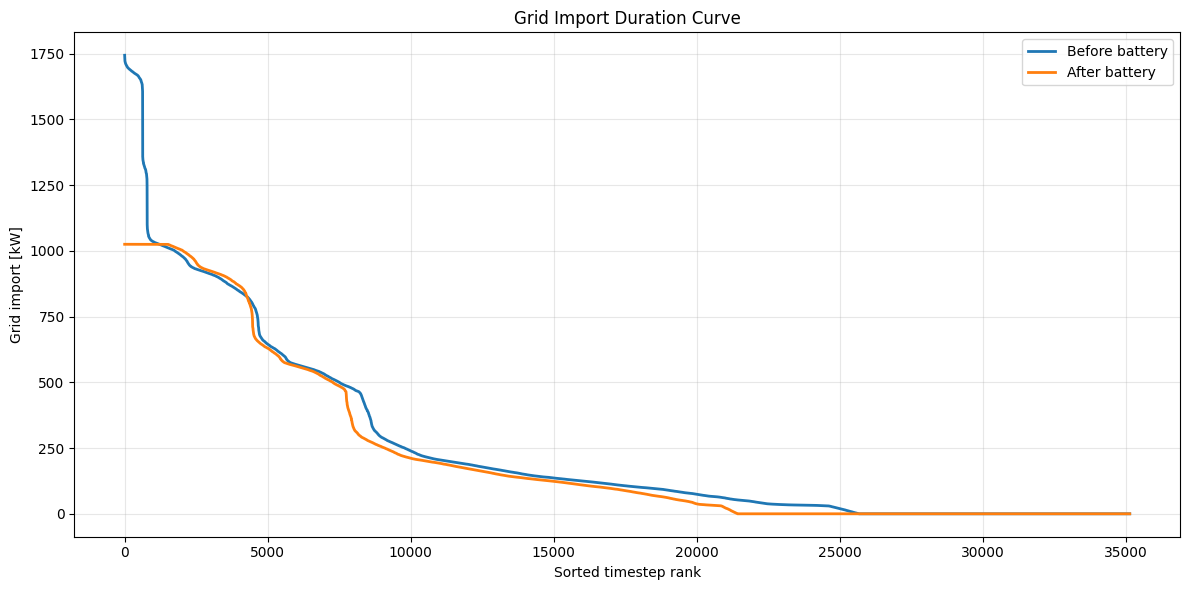

In [4]:
display(Markdown("## Grid Import Duration Curve"))

baseline_duration = df["baseline_grid_import"].sort_values(ascending=False).reset_index(drop=True)
optimized_duration = df["grid_flow"].sort_values(ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(baseline_duration.index + 1, baseline_duration, label="Before battery", linewidth=2)
ax.plot(optimized_duration.index + 1, optimized_duration, label="After battery", linewidth=2)
ax.set_xlabel("Sorted timestep rank")
ax.set_ylabel("Grid import [kW]")
ax.set_title("Grid Import Duration Curve")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
display(Markdown("## Monthly Savings and Peak Reduction"))
display(df_monthly.style.format({
    "monthly_import_cost_before": format_value,
    "monthly_import_cost_after": format_value,
    "monthly_savings": format_value,
    "monthly_peak_before": format_value,
    "monthly_peak_after": format_value,
    "monthly_peak_reduction": format_value,
}))

## Monthly Savings and Peak Reduction

,month,monthly_import_cost_before,monthly_import_cost_after,monthly_savings,monthly_peak_before,monthly_peak_after,monthly_peak_reduction
0,2024-01,"70,589.25","69,528.35","1,060.90","1,704.81","1,025.26",679.55
1,2024-02,"60,567.41","55,074.80","5,492.61","1,710.51","1,025.26",685.25
2,2024-03,"58,841.98","50,372.42","8,469.55","1,699.59","1,025.26",674.33
3,2024-04,"47,959.72","38,124.31","9,835.41","1,105.51","1,025.26",80.26
4,2024-05,"47,867.65","38,187.14","9,680.51","1,081.39","1,025.26",56.13
5,2024-06,"42,686.35","33,493.27","9,193.07","1,033.82","1,025.26",8.57
6,2024-07,"47,271.79","36,350.58","10,921.21","1,048.24","1,025.26",22.98
7,2024-08,"46,918.89","36,360.72","10,558.17","1,042.85","1,025.26",17.59
8,2024-09,"46,896.26","39,174.67","7,721.58","1,062.53","1,025.26",37.27
9,2024-10,"64,052.08","58,981.95","5,070.13","1,719.56","1,025.26",694.31


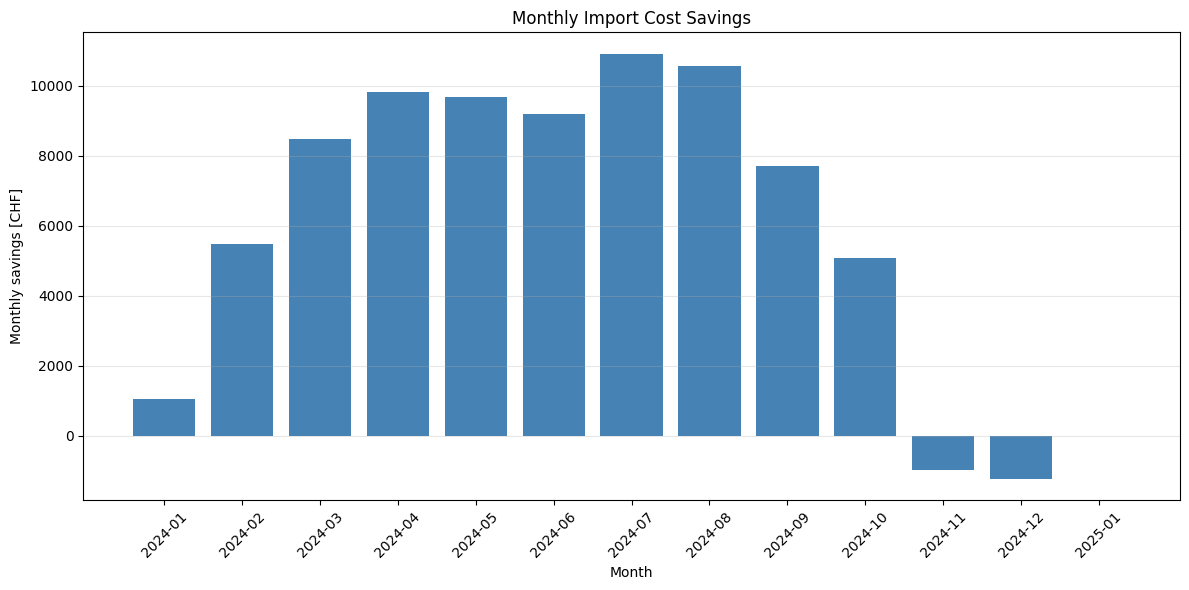

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_monthly["month"], df_monthly["monthly_savings"], color="steelblue")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly savings [CHF]")
ax.set_title("Monthly Import Cost Savings")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Power flows and battery SOC for a selected date range
start_date = "2025-11-03"  # inclusive
end_date = "2025-11-10"    # exclusive (set +7 days for one week)

start_ts = pd.Timestamp(start_date)
end_ts = pd.Timestamp(end_date)

date_mask = (df["timestamp"] >= start_ts) & (df["timestamp"] < end_ts)
df_sel = df.loc[date_mask].copy()

if df_sel.empty:
    print(f"No data available between {start_date} and {end_date}.")
else:
    # Approximate portion of battery charging that must come from the grid
    # (when charging power exceeds instantaneous PV flow)
    df_sel["grid_to_battery_proxy"] = (df_sel["battery_charge_power"] - df_sel["pv_flow"]).clip(lower=0)

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()

    ax1.plot(df_sel["timestamp"], df_sel["grid_flow"], color="tab:blue", linewidth=1.2, label="Grid power flow [kW]")
    ax1.plot(df_sel["timestamp"], df_sel["pv_flow"], color="tab:green", linewidth=1.2, label="PV power flow [kW]")
    ax1.fill_between(
        df_sel["timestamp"],
        0,
        df_sel["grid_to_battery_proxy"],
        color="tab:orange",
        alpha=0.25,
        label="Likely grid charging contribution [kW]",
    )

    ax2.plot(df_sel["timestamp"], df_sel["battery_soc"], color="tab:red", linewidth=1.4, label="Battery SOC [kWh]")

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Power flow [kW]")
    ax2.set_ylabel("Battery SOC [kWh]")
    ax1.set_title(f"Power Flows and Battery SOC ({start_date} to {end_date})")
    ax1.grid(axis="y", alpha=0.3)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

    plt.tight_layout()
    plt.show()

In [7]:
display(Markdown("## Battery Utilization Metrics"))
display(df_battery_util.style.format({"Value": format_value}))

## Battery Utilization Metrics

,Metric,Value,Unit
0,Charged energy,"596,862.45",kWh/year
1,Discharged energy,"510,326.64",kWh/year
2,Equivalent full cycles,385.63,cycles/year
3,Average state of charge,338.30,kWh
4,Minimum state of charge,-0.00,kWh
5,Maximum state of charge,"1,323.37",kWh
6,Hours near empty (<=10%),"4,750.00",hours
7,Hours near full (>=90%),697.25,hours
8,Maximum charge power used,"1,000.00",kW
9,Maximum discharge power used,980.74,kW


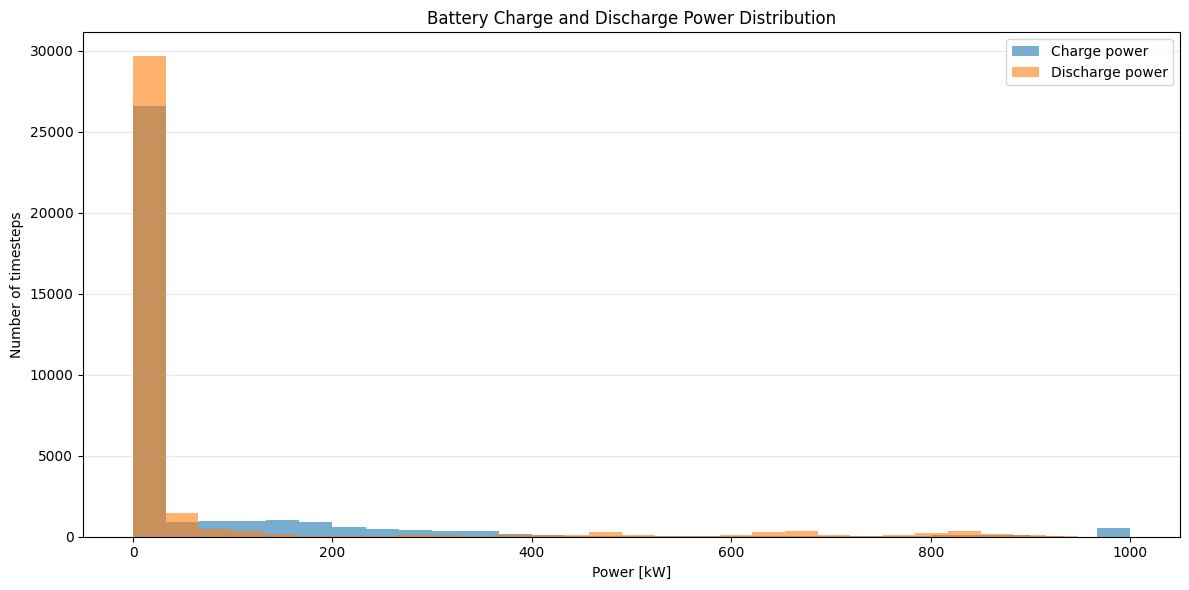

In [8]:
if {"battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(df["battery_charge_power"], bins=30, alpha=0.6, label="Charge power", color="tab:blue")
    ax.hist(df["battery_discharge_power"], bins=30, alpha=0.6, label="Discharge power", color="tab:orange")
    ax.set_xlabel("Power [kW]")
    ax.set_ylabel("Number of timesteps")
    ax.set_title("Battery Charge and Discharge Power Distribution")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_Run the model again to generate charge/discharge power distributions for this section._"))

In [9]:
display(Markdown("## Battery Size Sensitivity"))
if df_battery_sensitivity.empty:
    display(Markdown("_Run the model again to generate the battery size sensitivity analysis._"))
else:
    display(df_battery_sensitivity.style.format({
        "battery_size_kwh": format_value,
        "annual_savings": format_value,
        "npv": format_value,
        "payback_years": format_value,
        "discounted_payback_years": format_value,
    }))

## Battery Size Sensitivity

_Run the model again to generate the battery size sensitivity analysis._

In [10]:
plot_df = df_battery_sensitivity[df_battery_sensitivity["status"].isin(["baseline", "optimal"])].copy() if not df_battery_sensitivity.empty else df_battery_sensitivity
if not plot_df.empty:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(plot_df["battery_size_kwh"], plot_df["annual_savings"], marker="o", color="tab:blue")
    ax1.set_xlabel("Battery size [kWh]")
    ax1.set_ylabel("Annual savings [CHF/year]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(plot_df["battery_size_kwh"], plot_df["npv"], marker="s", color="tab:red")
    ax2.set_ylabel("NPV [CHF]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Sensitivity Plot of Battery Size vs NPV / Annual Savings")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_No sensitivity results available yet for this run._"))

_No sensitivity results available yet for this run._

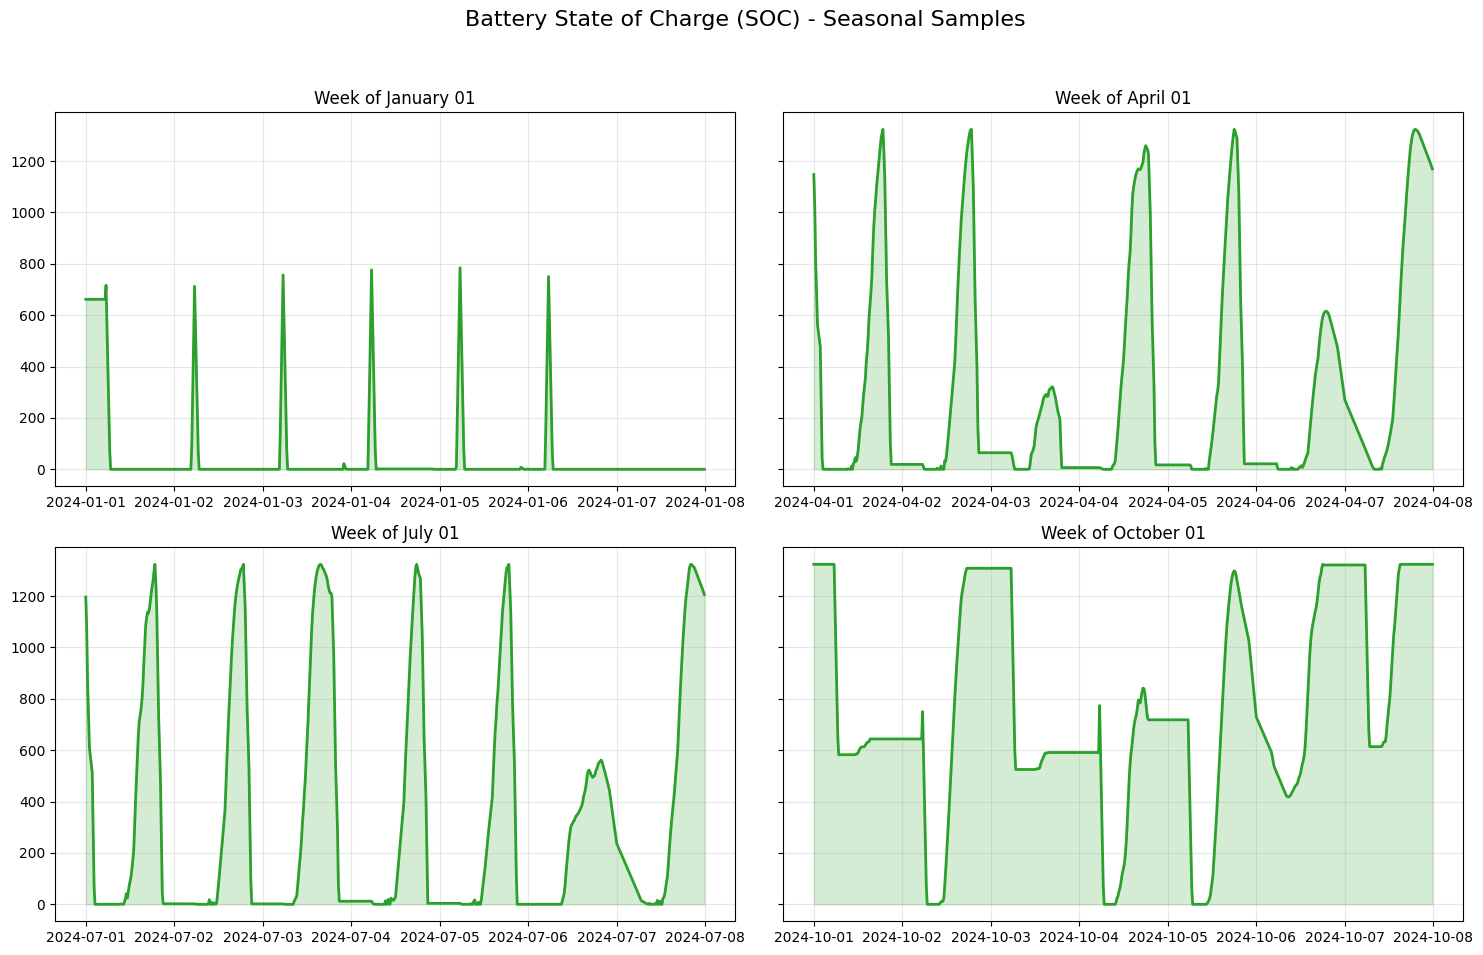

In [11]:
## 2. Battery State of Charge (Seasonal Samples)
if 'df_soc' not in globals():
    df_soc = df.copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()
dates = [f"{df_soc['timestamp'].dt.year.iloc[0]}-01-01", 
         f"{df_soc['timestamp'].dt.year.iloc[0]}-04-01", 
         f"{df_soc['timestamp'].dt.year.iloc[0]}-07-01", 
         f"{df_soc['timestamp'].dt.year.iloc[0]}-10-01"]

for i, start_date in enumerate(dates):
    start = pd.to_datetime(start_date)
    end = start + pd.Timedelta(days=7)
    mask = (df_soc['timestamp'] >= start) & (df_soc['timestamp'] < end)
    
    ax = axes[i]
    if mask.any():
        ax.plot(df_soc.loc[mask, 'timestamp'], df_soc.loc[mask, 'battery_soc'], color='#2ca02c', lw=2)
        ax.fill_between(df_soc.loc[mask, 'timestamp'], df_soc.loc[mask, 'battery_soc'], alpha=0.2, color='#2ca02c')
        ax.set_title(f"Week of {start.strftime('%B %d')}")
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No Data", ha='center')

plt.suptitle("Battery State of Charge (SOC) - Seasonal Samples", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

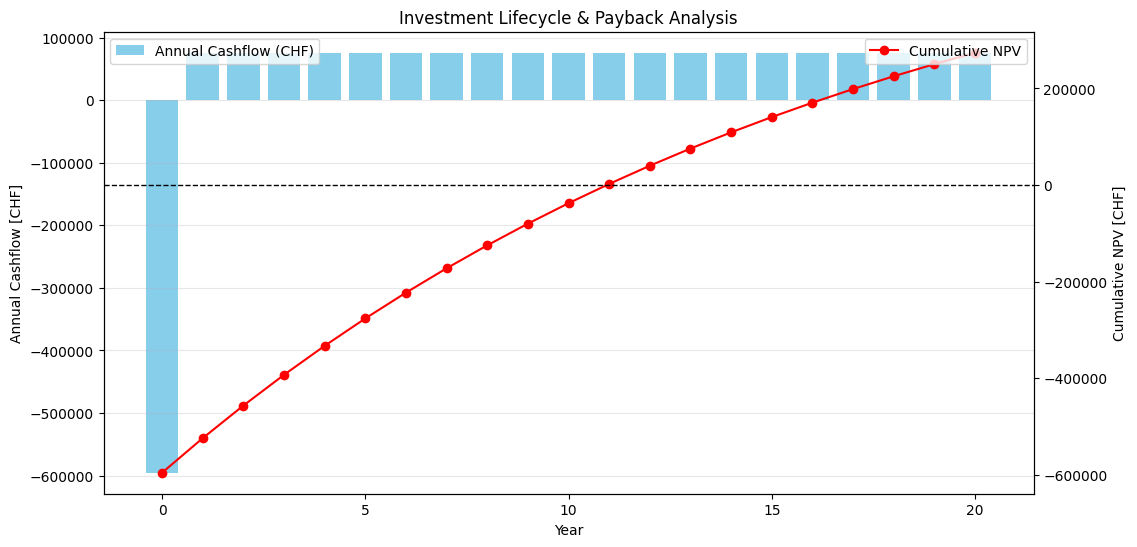

**Payback Period:** 8 years

**Discounted Payback Period:** 11 years

**Net Present Value (NPV):** CHF 273,848.95

In [12]:
## 3. Financial Projection
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_fin['year'], df_fin['cashflow'], color='skyblue', label='Annual Cashflow (CHF)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Cashflow [CHF]')

ax2 = ax1.twinx()
ax2.plot(df_fin['year'], df_fin['discounted_cashflow'].cumsum(), color='red', marker='o', label='Cumulative NPV')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_ylabel('Cumulative NPV [CHF]')

plt.title("Investment Lifecycle & Payback Analysis")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
plt.show()

display(Markdown(f"**Payback Period:** {summary.get('payback_years', 'N/A')} years"))
display(Markdown(f"**Discounted Payback Period:** {summary.get('discounted_payback_years', 'N/A')} years"))
display(Markdown(f"**Net Present Value (NPV):** CHF {summary.get('npv', 0):,.2f}"))